In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from timm import create_model
from pathlib import Path
from model.image_dataset import ImageDataset
from model.classification import ClassificationType
from tqdm import tqdm
import timm
import numpy as np

In [23]:
BATCH_SIZE = 128
EPOCHS = 20
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, "data", "processed")

cuda:0


# Testing metrics

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [8]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.4104351758956909, 0.4893591821193695, 0.4897149622440338]
train_transform  = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
val_path = Path(os.path.join(data_dir, "val"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, train_transform)
val_dataset = ImageDataset(val_path, eval_transform)
test_dataset = ImageDataset(test_path, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, "Evaluating", total=len(dataloader)):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall (sensitivity)': recall,
        'f1-score': f1
    }

num_classes = ClassificationType.get_number_of_types()
model = timm.create_model('resnet50', pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("MODEL2.pth"))
model = model.to(device)


train_metrics = evaluate_model(model, train_loader, device)
val_metrics = evaluate_model(model, val_loader, device)
test_metrics = evaluate_model(model, test_loader, device)

Evaluating:  55%|█████▌    | 756/1373 [02:32<02:02,  5.05it/s]C:\Users\kubas\anaconda3\envs\deeplearning\Lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 173/173 [00:34<00:00,  4.95it/s]


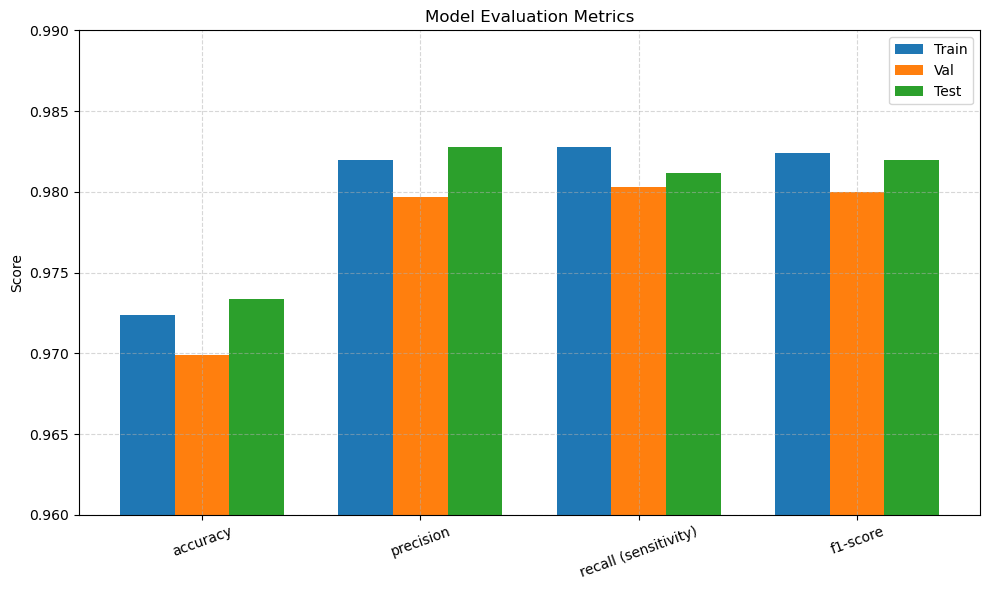

In [12]:
labels = list(train_metrics.keys())
x = np.arange(len(labels))
width = 0.25

train_vals = list(train_metrics.values())
val_vals = list(val_metrics.values())
test_vals = list(test_metrics.values())

plt.figure(figsize=(10, 6))
plt.bar(x - width, train_vals, width, label='Train')
plt.bar(x, val_vals, width, label='Val')
plt.bar(x + width, test_vals, width, label='Test')

plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(x, labels, rotation=20)
plt.ylim(0.96, 0.99)
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [25]:
data_dir = os.path.join(parent_dir, "data", "cropped")

mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.4104351758956909, 0.4893591821193695, 0.4897149622440338]
train_transform  = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.1, 0.1),   
        shear=10               
    ),
    transforms.ColorJitter(
        brightness=0.2, 
        contrast=0.2, 
        saturation=0.2, 
        hue=0.1 
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
val_path = Path(os.path.join(data_dir, "val"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, train_transform)
val_dataset = ImageDataset(val_path, eval_transform)
test_dataset = ImageDataset(test_path, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
train_metrics_history = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1-score': []
}

val_metrics_history = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1-score': []
}

best_val_f1 = 0.0
best_val_accuracy = 0.0

num_classes = ClassificationType.get_number_of_types()
model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL2_fine_tuned.pth"

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def get_metrics(preds, labels):
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall': recall_score(labels, preds, average='macro', zero_division=0),
        'f1-score': f1_score(labels, preds, average='macro', zero_division=0)
    }

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    all_train_preds = []
    all_train_labels = []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_train_preds.extend(preds)
        all_train_labels.extend(labels)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_metrics = get_metrics(torch.stack(all_train_preds), torch.stack(all_train_labels))
    for key in train_metrics:
        train_metrics_history[key].append(train_metrics[key])

    # Validation
    model.eval()
    val_running_loss = 0.0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_val_preds.extend(preds)
            all_val_labels.extend(labels)

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_metrics = get_metrics(torch.stack(all_val_preds), torch.stack(all_val_labels))
    for key in val_metrics:
        val_metrics_history[key].append(val_metrics[key])

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    print(f"Train Metrics: {train_metrics}")
    print(f"Val Metrics: {val_metrics}")

    if avg_val_loss < best_val_loss and (
        val_metrics['f1-score'] > best_val_f1 or
        val_metrics['accuracy'] > best_val_accuracy
    ):
        best_val_loss = avg_val_loss
        best_val_f1 = val_metrics['f1-score']
        best_val_accuracy = val_metrics['accuracy']
        torch.save(model.state_dict(), best_model_path)
        print("New best model saved (based on val_loss + f1 or accuracy)")
    
    scheduler.step()

Epoch 1/20:   1%|          | 12/1287 [00:11<18:45,  1.13it/s]

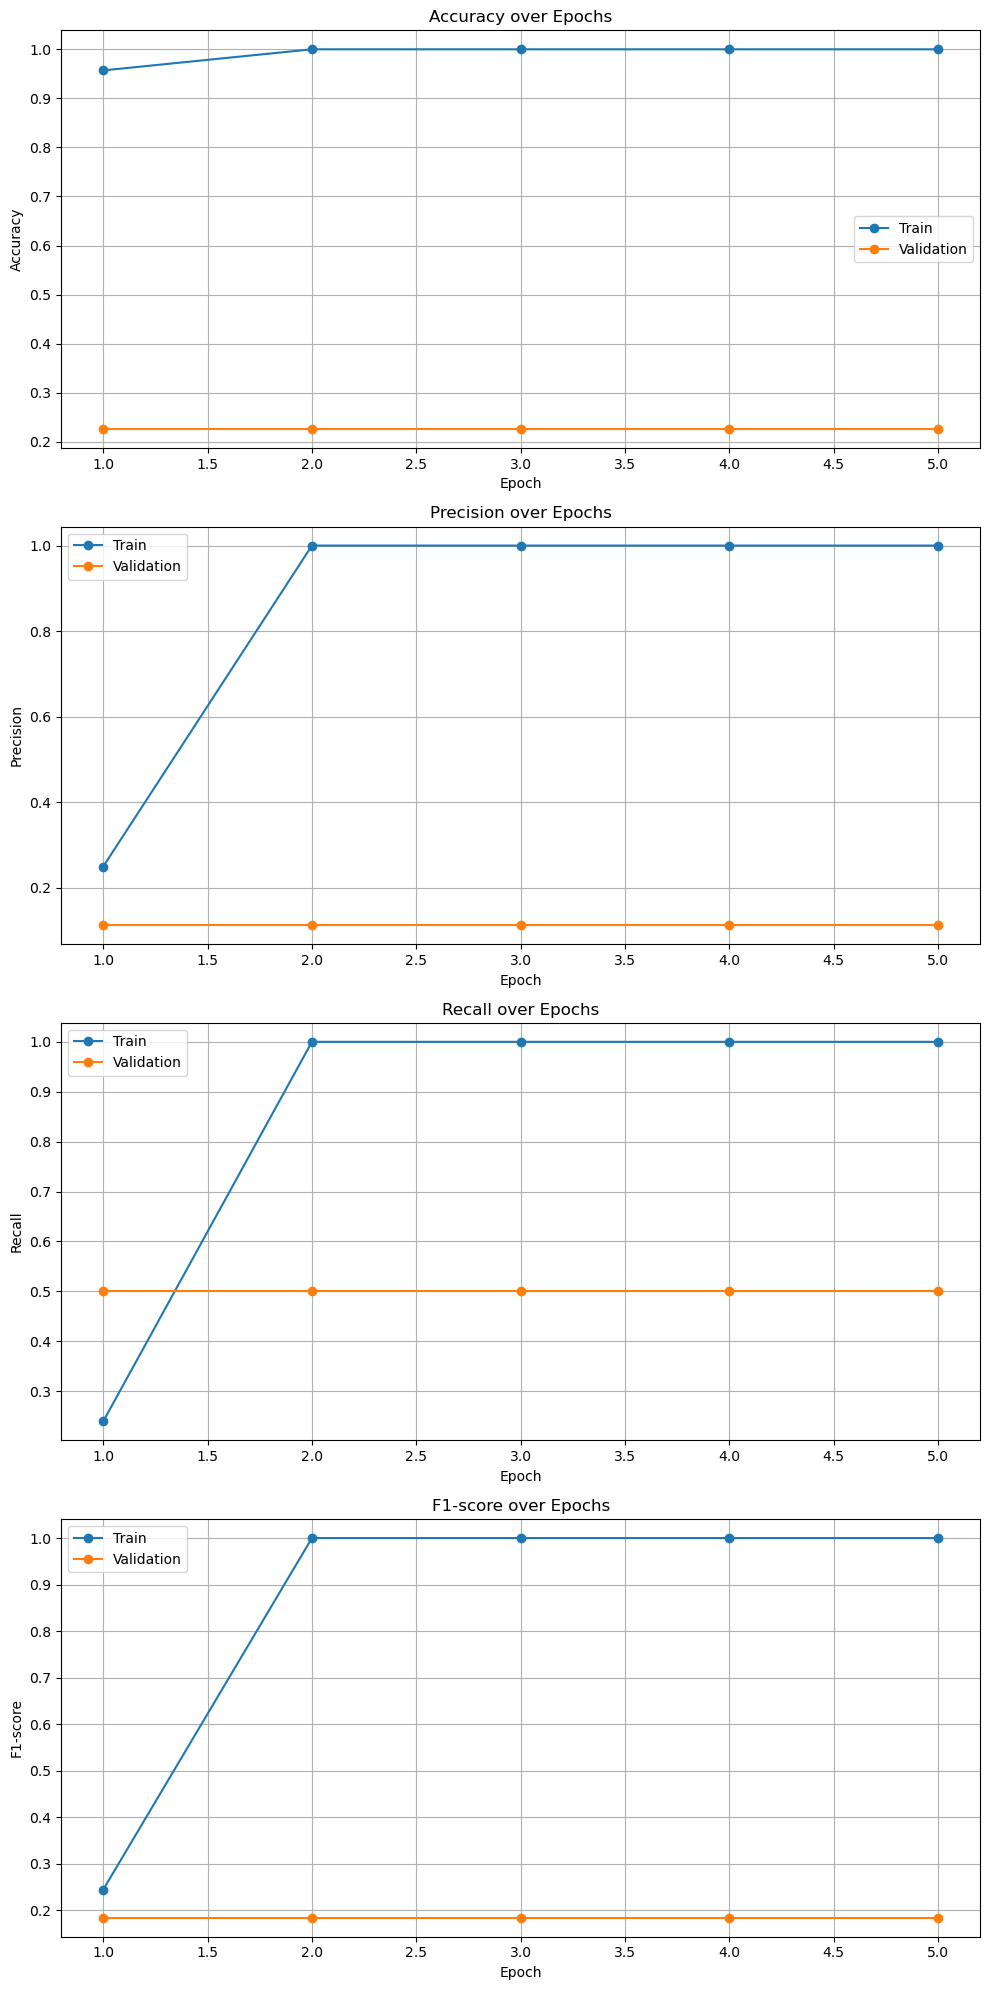

In [16]:
metrics = ['accuracy', 'precision', 'recall', 'f1-score']
epochs = list(range(1, len(train_metrics_history['accuracy']) + 1))

plt.figure(figsize=(10, 20))

for i, metric in enumerate(metrics, 1):
    plt.subplot(len(metrics), 1, i)
    plt.plot(epochs, train_metrics_history[metric], label='Train', marker='o')
    plt.plot(epochs, val_metrics_history[metric], label='Validation', marker='o')
    plt.title(f'{metric.capitalize()} over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()